**Normalized Fragment Length Frequency**

You are given a file where each line represents the mapping of a DNA fragment on a chromosome. Each fragment spans from a start to an end position. The task is to:

1. Calculate the fragment length for each line as the difference between the 3rd and 2nd columns (i.e., end - start).

2. Count the frequency of each unique fragment length.

3. Normalize these frequencies by dividing by the total number of fragments.

4. Plot the normalized frequency distribution of fragment lengths using a suitable Python plotting library.

 i.  The X-axis of the plot should represent the fragment length (in base pairs).

 ii. The Y-axis should be labeled as "Normalized Frequency [A.U.]" (arbitrary units).

Rescaling

Read the reference.hist file, which contains a histogram of fragment lengths and their normalized frequencies.
Rescale the data from query.bed.gz such that the normalized fragment length distribution from query closely matches the one in reference.

Plot both distributions (before and after rescaling) to demonstrate the effect:
Use different colors/legends to distinguish them.
Ensure both curves are on the same axes.

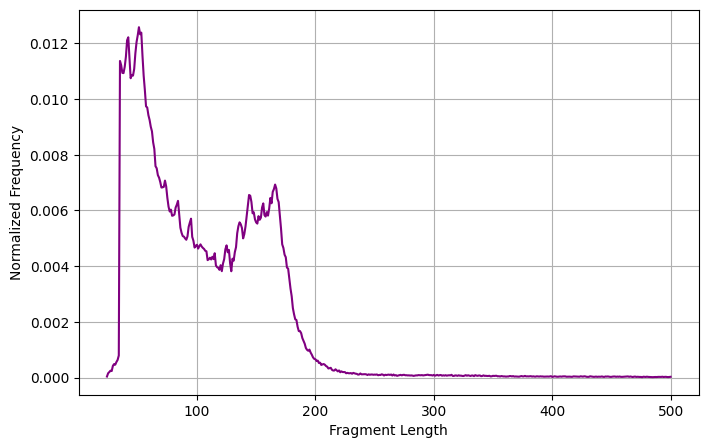

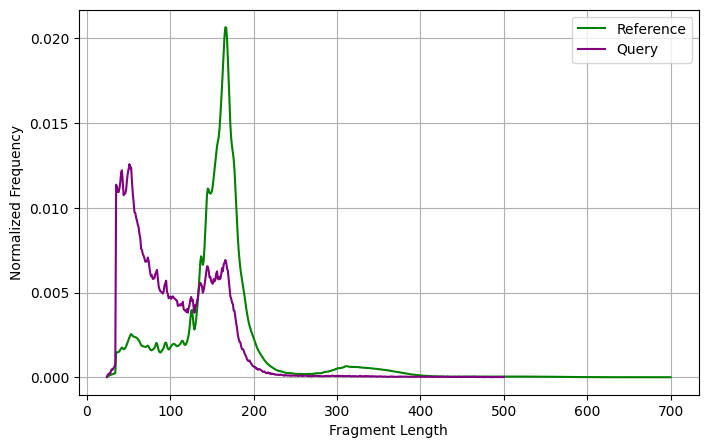

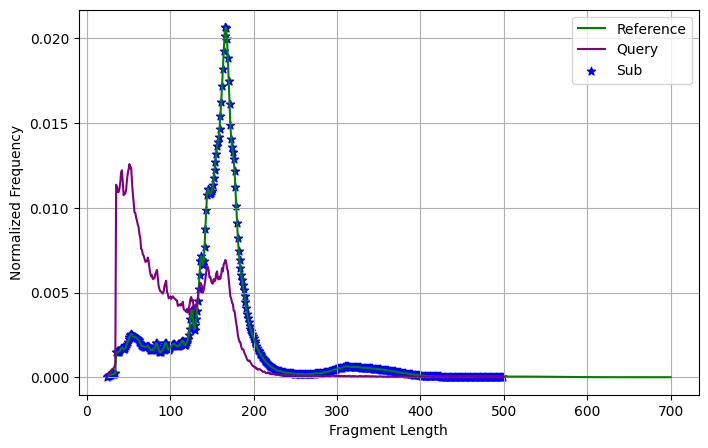

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter

df0 = pd.read_csv('/mnt/query.bed', sep='\t', header=None)
counts = Counter(df0.iloc[:, 2]-df0.iloc[:,1])
total = sum(counts.values())
norm_freq = {k: v / total for k, v in counts.items()}

x, y = zip(*sorted(norm_freq.items()))
df1 = pd.DataFrame({'Fragment Length': x, 'Normalized Frequency': y})

plt.figure(figsize=(8, 5))
plt.plot(df1.iloc[:,0], df1.iloc[:,1], color='purple')
plt.xlabel('Fragment Length')
plt.ylabel('Normalized Frequency')
plt.grid(True)
plt.show()

df2 = pd.read_csv('/mnt/reference.hist', sep='\t', header=None)
plt.figure(figsize=(8, 5))
plt.plot(df2.iloc[:,0], df2.iloc[:,1], color='green',label='Reference')
plt.plot(x, y, color='purple',label='Query')
plt.legend()
plt.xlabel('Fragment Length')
plt.ylabel('Normalized Frequency')
plt.grid(True)
plt.show()

bins = list(range(0, 510, 10))
labels = [f"{i}-{i+10}" for i in range(0, 500, 10)]

df1['bin'] = pd.cut(df1.iloc[:,0], bins=bins, labels=labels, right=False)
df2['bin'] = pd.cut(df2.iloc[:,0], bins=bins, labels=labels, right=False)

df1_cnt = df1['bin'].value_counts().sort_index()
df2_cnt = df2['bin'].value_counts().sort_index()

smp_rows = []

for bin_label in labels:
    count_df1 = df1_cnt.get(bin_label, 0)
    count_df2 = df2_cnt.get(bin_label, 0)

    smp_size = min(count_df1, count_df2)

    if smp_size > 0:
        df2_bin_rows = df2[df2['bin'] == bin_label]
        smp = df2_bin_rows.sample(n=smp_size, random_state=42)
        smp_rows.append(smp)

result = pd.concat(smp_rows, ignore_index=True)

plt.figure(figsize=(8, 5))
plt.plot(df2.iloc[:,0], df2.iloc[:,1], color='green',label='Reference')
plt.plot(x, y, color='purple',label='Query')
plt.scatter(result.iloc[:,0], result.iloc[:,1], color='blue',label='Sub',marker="*")
plt.legend()
plt.xlabel('Fragment Length')
plt.ylabel('Normalized Frequency')
plt.grid(True)
plt.show()